# 🧠 Dino CNN - Vegetable Classification
This notebook trains a CNN on a vegetable dataset using PyTorch.

Generated on: 2026-02-18 08:01:23.694364

In [10]:
# ==============================
# 0. Imports
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os


In [11]:
# ==============================
# 1. Device (Mac M-series safe)
# ==============================
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)


Using device: mps


In [12]:
# ==============================
# 2. Paths (EDIT ONLY THIS IF NEEDED)
# ==============================
TRAIN_DIR = '/Users/satviksingh/Documents/ manas_git/GitHub/satvik_VII/working_directory/neural net problems/A,B,CNNS_with_Tim/veggie_heap_training'
TEST_DIR = '/Users/satviksingh/Documents/ manas_git/GitHub/satvik_VII/working_directory/neural net problems/A,B,CNNS_with_Tim/veggie_heap_testing'


In [13]:
# ==============================
# 3. Transforms + DataLoaders
# ==============================
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

print('Classes:', train_dataset.classes)
print('Number of classes:', num_classes)


Classes: ["Apatosaur Aphie's Apples", "Bluplocephalus Bob's Blueberries", "Cherizinoasaur Cher's Cherries", "Corythosaurus Cory's Corn", "Grapthorina Greta's Grapes", "Pachycephalosaurus Perry's Peaches", "Pepteranodon Pep's Peppers", "Potoceratops Pott's Potatoes", "Rhaspdodon Ribery's Raspberries", "Stribecosaurus Stan's Strawberries", "Thyreosaur Tim's Thyme", 'vacation_photos']
Number of classes: 12


In [14]:
# ==============================
# 4. CNN Model
# ==============================
class DinoCNN(nn.Module):
    def __init__(self, num_classes):
        super(DinoCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = DinoCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [15]:
# ==============================
# 5. Training
# ==============================
epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}")


Epoch [1/30] Loss: 1.0103 Accuracy: 0.7625
Epoch [2/30] Loss: 0.7277 Accuracy: 0.8215
Epoch [3/30] Loss: 0.6320 Accuracy: 0.8403
Epoch [4/30] Loss: 0.5438 Accuracy: 0.8614
Epoch [5/30] Loss: 0.4229 Accuracy: 0.8987
Epoch [6/30] Loss: 0.4601 Accuracy: 0.8902
Epoch [7/30] Loss: 0.3767 Accuracy: 0.9083
Epoch [8/30] Loss: 0.3613 Accuracy: 0.9063
Epoch [9/30] Loss: 0.2319 Accuracy: 0.9361


KeyboardInterrupt: 

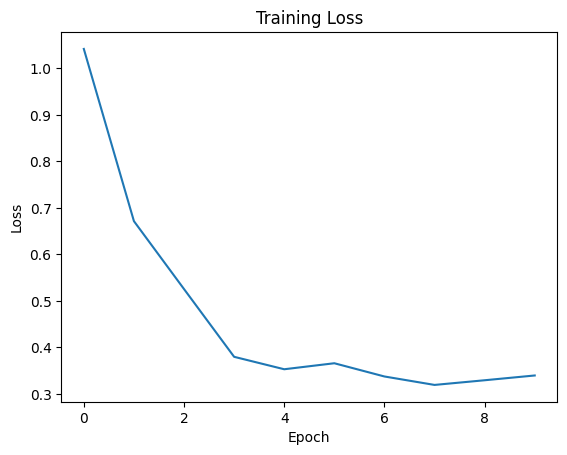

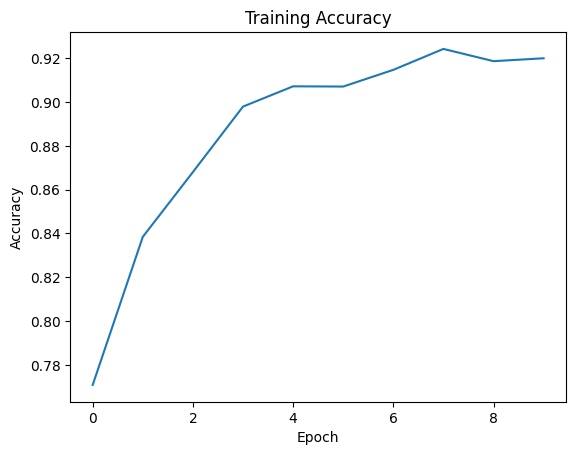

In [ ]:
# ==============================
# 6. Plot Training Graphs
# ==============================
plt.figure()
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()


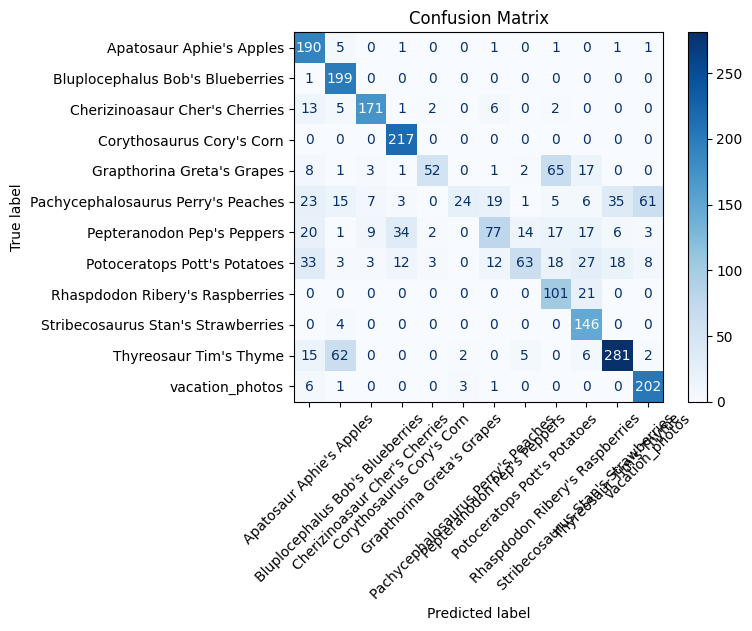

In [ ]:
# ==============================
# 7. Confusion Matrix
# ==============================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()


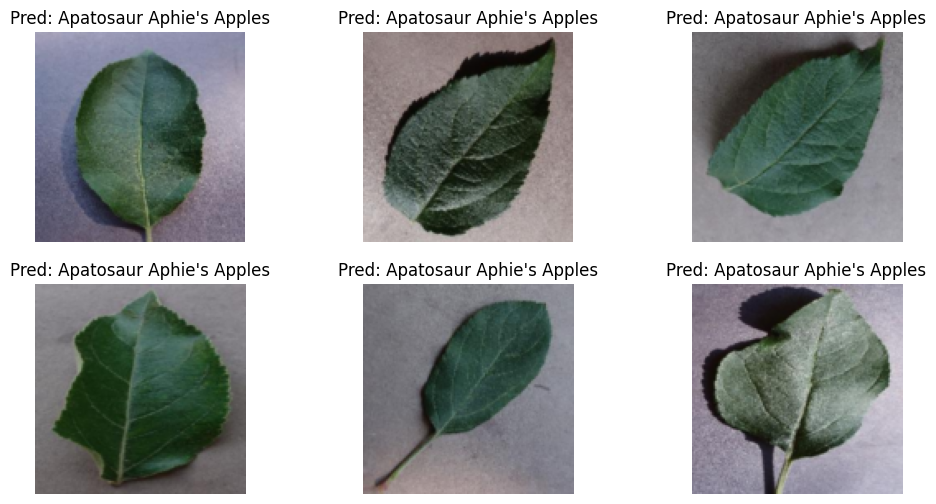

In [ ]:
# ==============================
# 8. Show Sample Predictions
# ==============================
def show_predictions():
    model.eval()
    images, labels = next(iter(test_loader))
    images = images.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig = plt.figure(figsize=(12, 6))

    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1)

        img = images[i].cpu()
        img = img * 0.5 + 0.5
        img = img.permute(1, 2, 0)

        plt.imshow(img)
        ax.set_title(f"Pred: {train_dataset.classes[preds[i]]}")
        plt.axis('off')

    plt.show()

show_predictions()
